# Notebook 3 — ML Evaluation & EMH Test

**Bachelor thesis:** Testing Market Efficiency: Evidence from the US Dollar Index and Emerging Markets *(MSCI Emerging Markets ETF — EEM)*

---

**Previous notebooks:** Notebook 01 produced the processed dataset (`eem_dataset_features/target.csv`). Notebook 02 established the econometric baselines (ARIMA, ARIMAX, GARCH, Ridge, Lasso) — familiarity with those results is assumed.

**This notebook:**
1. Build ML feature set — EEM lags, 9 cross-asset returns, 21- and 63-day rolling volatility
2. Fit **Random Forest**, **Gradient Boosting (XGBoost)** and **SVR** with GridSearchCV + TimeSeriesSplit
3. Fit **univariate ARIMA+GARCH** (for order selection) and **ARIMAX+GARCH** with the **same (p,d,q) as notebook 02**; **ARIMA(0,0,0)** as the white-noise baseline for rolling OOS
4. Generate rolling one-step-ahead out-of-sample forecasts for all five models (refit every 21 days)
5. Compare all five models — RMSE, MAE, R², directional accuracy, hit ratio
6. **Diebold-Mariano test** (HLN-corrected): is any model significantly better than the random-walk baseline?
7. **Binomial test**: does directional accuracy differ significantly from 50%?
8. **Block Permutation Test** (21-day blocks, 200 permutations): does training on real returns outperform training on block-shuffled returns?
9. Save all five fitted models to disk

**Conclusion:** if no model significantly beats ARIMA(0,0,0), the data are consistent with the **Efficient Market Hypothesis**.

**Output:** `arima_nb3.pkl`, `arimax_nb3.pkl`, `rf_model.pkl`, `gb_model.pkl`, `svr_model.pkl` saved to `models/`.

> *Note: sample starts ~63 observations later than notebook 02 due to the 63-day rolling volatility warm-up period.*

Library imports: pandas, numpy, scikit-learn (RF, XGBoost, SVR, GridSearchCV, TimeSeriesSplit), and project modules (`MLModel`, `ARIMAModel`, `TwoStepARIMAGARCHModel`, `ARIMAGARCHModel`, `MetricsCalculator`, `ModelComparator`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_val_score
from xgboost import XGBRegressor
from sklearn.svm import SVR

import sys
from pathlib import Path

for _p in [Path.cwd().resolve(), Path.cwd().resolve().parent]:
    if (_p / "src" / "models" / "arimagarch_model.py").is_file():
        if str(_p) not in sys.path:
            sys.path.insert(0, str(_p))
        break

from config import config, MODELS_DIR
from src.data.processor import DataProcessor
from src.models.arima_model import ARIMAModel
from src.models.twostep_model import TwoStepARIMAGARCHModel

import importlib
import src.models.arimagarch_model as _am_module
importlib.reload(_am_module)
from src.models.arimagarch_model import ARIMAGARCHModel

from src.models.ml_models import MLModel
from src.validation.metrics import MetricsCalculator
from src.validation.model_comparison import ModelComparator

print(f"✓ ARIMAGARCHModel loaded from: {_am_module.__file__}")
print(f"✓ Has _arch_forecast_x_from_result: {hasattr(ARIMAGARCHModel, '_arch_forecast_x_from_result')}")
print("✓ All imports successful!")


✓ ARIMAGARCHModel loaded from: C:\Users\rosts\Desktop\Python\Projects\Diplom - copy\EMCI_part\src\models\arimagarch_model.py
✓ Has _arch_forecast_x_from_result: True
✓ All imports successful!


## 1. Data and Features

Load the processed dataset saved in notebook 01. Feature set for ML models and ARIMAX:
- **EEM return lags** (lag 1, 2, 3, 5) — autoregressive structure
- **9 cross-asset returns** (DXY, VIX, TNX, Oil, Copper, Gold, S&P 500, CNY, JPY) — shifted by 1 day to prevent look-ahead bias
- **Rolling volatility** (21-day and 63-day std of EEM returns) — shifted by 1 day

ARIMA(0,0,0) uses y only (EEM returns).

In [2]:
processor = DataProcessor()
X_full, y = processor.load_processed_data(name='eem_dataset')

lag_cols = [c for c in X_full.columns if 'target' in c and 'lag' in c.lower()]
exog_cols = [c for c in config.data.feature_tickers if c in X_full.columns]

X = X_full[lag_cols + exog_cols].copy()
X['vol_21'] = y.rolling(21).std()
X['vol_63'] = y.rolling(63).std()
X = X.dropna()
y = y.loc[X.index]

shift_cols = exog_cols + ['vol_21', 'vol_63']
X[shift_cols] = X[shift_cols].shift(1)
X = X.dropna()
y = y.loc[X.index]
exog = X[exog_cols]

print(f"✓ Features: {X.shape[1]} cols = {len(lag_cols)} EEM lags + {len(exog_cols)} exog + 2 vol")
print(f"  Lags: {lag_cols}")
print(f"  Exog: {exog_cols}")
print(f"  Samples: {len(X)} ({y.index.min().date()} to {y.index.max().date()})")

✓ Features: 15 cols = 4 EEM lags + 9 exog + 2 vol
  Lags: ['target_lag1', 'target_lag2', 'target_lag3', 'target_lag5']
  Exog: ['DX-Y.NYB', '^VIX', '^TNX', 'CL=F', 'HG=F', 'GC=F', '^GSPC', 'CAD=X', 'JPY=X']
  Samples: 5258 (2005-05-03 to 2026-03-30)


Chronological 80/20 train/test split. `StandardScaler` is fitted on training data only and applied to the test set to prevent data leakage. The scaler is also re-fitted inside each rolling window.

In [3]:
train_size = int(len(y) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"✓ Training: {len(y_train)} samples ({y_train.index.min().date()} to {y_train.index.max().date()})")
print(f"✓ Testing:  {len(y_test)} samples ({y_test.index.min().date()} to {y_test.index.max().date()})")

✓ Training: 4206 samples (2005-05-03 to 2022-01-18)
✓ Testing:  1052 samples (2022-01-19 to 2026-03-30)


## 2. Baselines: ARIMA(0,0,0), two-step ARIMA/ARIMAX+GARCH, and joint AR/ARX+GARCH


**ARIMA(0,0,0)** — white-noise baseline (random walk with constant mean). Under the
Efficient Market Hypothesis no model should significantly outperform this benchmark.

**ARIMAX(p,d,q)+GARCH(1,1)** — two-step model with exogenous cross-asset variables.
**Same rule as notebook 02:** fit **univariate** `ARIMA(p,d,q)+GARCH` on `y_train` first (`auto_arima` selects the order); then fit **ARIMAX+GARCH** with **`auto_arima` on `y_train` + exog** (no `order=` passed — **(p,d,q)** may differ from the ARIMA branch). Exog = same 9 cross-asset columns as notebook 02. Serves as the econometric reference for ML against the two-step semi-strong benchmark.

**Joint AR(p)+GARCH(1,1)** and **Joint ARX(p)+GARCH(1,1)** (`ARIMAGARCHModel`, `arch` MLE) mirror notebook 02: **separate AIC** lag search for the univariate and exogenous cases — **not** tied to `auto_arima` (p,d,q). Rolling OOS uses the same `refit_every=21` design.


In [4]:
arima = ARIMAModel(order=(0, 0, 0), auto_select=False)
arima.fit(y_train)
print("✓ ARIMA(0,0,0) baseline fitted")

exog_train = exog.loc[y_train.index]

# Same (p,d,q) as notebook 02: univariate auto_arima first, then ARIMAX with order=
arima_garch = TwoStepARIMAGARCHModel(max_p=5, max_q=5, max_d=1, dist='t',
                                      information_criterion='aic')
arima_garch.fit(y_train)
print(f"✓ ARIMA{arima_garch.order}+GARCH(1,1) fitted (ARIMAX order selected separately with exog, cf. notebook 02)")
print(f"  ARIMA_LL = {arima_garch.arima_llf:.2f}   GARCH_LL = {arima_garch.garch_llf:.2f}")

arimax_garch = TwoStepARIMAGARCHModel(max_p=5, max_q=5, max_d=1, dist='t',
                                       information_criterion='aic')
arimax_garch.fit(y_train, exog=exog_train)
axg_label = f"ARIMAX{arimax_garch.order}+GARCH(1,1)"
print(f"✓ {axg_label} fitted")
print(f"  ARIMA_LL = {arimax_garch.arima_llf:.2f}   GARCH_LL = {arimax_garch.garch_llf:.2f}")
joint_ar = ARIMAGARCHModel(max_lags=5, information_criterion="aic")
joint_ar.fit(y_train)
joint_arx = ARIMAGARCHModel(max_lags=5, information_criterion="aic")
joint_arx.fit(y_train, exog=exog_train)
jar_label = f"Joint AR({joint_ar.best_lags})+GARCH(1,1)"
jarx_label = f"Joint ARX({joint_arx.best_lags})+GARCH(1,1)"
print(f"✓ {jar_label} fitted  LL={joint_ar.loglikelihood:.2f}")
print(f"✓ {jarx_label} fitted  LL={joint_arx.loglikelihood:.2f}")


✓ ARIMA(0,0,0) baseline fitted
✓ ARIMA(2, 0, 1)+GARCH(1,1) fitted (ARIMAX order selected separately with exog, cf. notebook 02)
  ARIMA_LL = 10844.31   GARCH_LL = -7400.87
✓ ARIMAX(2, 0, 1)+GARCH(1,1) fitted
  ARIMA_LL = 10893.57   GARCH_LL = -7381.69
✓ Joint AR(5)+GARCH(1,1) fitted  LL=-7363.25
✓ Joint ARX(5)+GARCH(1,1) fitted  LL=-7339.01


## 3. ML Models — Hyperparameter Tuning

All three ML models (Random Forest, Gradient Boosting via XGBoost, SVR) are tuned with `GridSearchCV` using `TimeSeriesSplit(n_splits=5)`. This avoids standard k-fold cross-validation, which would introduce future-to-past information leakage on time series data.

Best parameters are extracted and used to initialise `MLModel` instances for the rolling forecast phase.

In [5]:
tscv = TimeSeriesSplit(n_splits=5)

# rf_param_grid = {
#     'n_estimators':     [100, 200, 500, 1000],
#     'max_depth':        [None, 3, 5, 7, 10],
#     'min_samples_leaf': [5, 10, 20, 50],
#     'min_samples_split':[2, 10, 20],
#     'max_features':     ['sqrt', 'log2', None],
#     'bootstrap':        [True, False]
# }
# RF best params grid for focused retrain
rf_param_grid = {
    'n_estimators':     [500],
    'max_depth':        [5],
    'min_samples_leaf': [5],
    'min_samples_split':[2],
    'max_features':     ['sqrt'],
    'bootstrap':        [True]
}


rf_gs = GridSearchCV(
    RandomForestRegressor(random_state=config.RANDOM_SEED, n_jobs=-1),
    rf_param_grid, cv=tscv, scoring='neg_mean_squared_error',
    n_jobs=-1, verbose=1
)
rf_gs.fit(X_train_s, y_train)
print(f"✓ RF best params: {rf_gs.best_params_}")

Fitting 5 folds for each of 1 candidates, totalling 5 fits
✓ RF best params: {'bootstrap': True, 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 500}


In [6]:
gb_param_grid = {
    'n_estimators':    [25, 50, 100, 200, 300],
    'max_depth':       [2, 3, 5],
    'learning_rate':   [0.01, 0.05, 0.1],
    'min_child_weight':[1, 5, 10],
    'subsample':       [0.8, 1.0],
    'colsample_bytree':[0.8, 1.0]
}

gb_gs = GridSearchCV(
    XGBRegressor(random_state=config.RANDOM_SEED, n_jobs=-1, verbosity=0),
    gb_param_grid, cv=tscv, scoring='neg_mean_squared_error',
    n_jobs=-1, verbose=1
)
gb_gs.fit(X_train_s, y_train)
print(f"✓ GB best params: {gb_gs.best_params_}")

Fitting 5 folds for each of 540 candidates, totalling 2700 fits
✓ GB best params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 25, 'subsample': 0.8}


In [7]:
# svr_param_grid = {
#     'kernel':  ['rbf'],
#     'C':       [1, 10, 100, 1000],
#     'gamma':   ['scale', 0.1, 0.01, 0.001],
#     'epsilon': [0.001, 0.005, 0.01, 0.05, 0.1]
# }

svr_param_grid = {'C': [1], 'epsilon': [0.01], 'gamma': [0.001], 'kernel': ['rbf']}

svr_gs = GridSearchCV(
    SVR(),
    svr_param_grid, cv=tscv, scoring='neg_mean_squared_error',
    n_jobs=-1, verbose=1
)
svr_gs.fit(X_train_s, y_train)
print(f"✓ SVR best params: {svr_gs.best_params_}")
print("✓ All three ML models tuned via GridSearchCV")

Fitting 5 folds for each of 1 candidates, totalling 5 fits
✓ SVR best params: {'C': 1, 'epsilon': 0.01, 'gamma': 0.001, 'kernel': 'rbf'}
✓ All three ML models tuned via GridSearchCV


### Model Quality Validation — GridSearchCV Improvement

**Purpose:** verify that hyperparameter tuning actually improved models relative to default parameters. If tuned CV RMSE < default CV RMSE, the GridSearchCV configuration was effective — the improvement is not accidental.

This step validates that the models are **well-configured** before interpreting OOS results for EMH.

In [8]:
from sklearn.base import clone

print("=" * 65)
print("  GRIDSEARCHCV IMPROVEMENT: default vs tuned CV RMSE")
print("  (5-fold TimeSeriesSplit on training data)")
print("=" * 65)
print(f"\n{'Model':<22} {'Default CV RMSE':>16} {'Tuned CV RMSE':>14} {'Improvement':>12}")
print("-" * 68)

default_estimators = [
    ('Random Forest',  RandomForestRegressor(random_state=config.RANDOM_SEED, n_jobs=-1), rf_gs),
    ('Grad. Boosting', XGBRegressor(random_state=config.RANDOM_SEED, n_jobs=-1, verbosity=0), gb_gs),
    ('SVR',            SVR(), svr_gs),
]

for name, default_est, gs in default_estimators:
    tuned_cv_rmse   = np.sqrt(-gs.best_score_)
    default_scores  = cross_val_score(
        clone(default_est), X_train_s, y_train,
        cv=tscv, scoring='neg_mean_squared_error', n_jobs=-1
    )
    default_cv_rmse = np.sqrt(-default_scores.mean())
    improvement_pct = (default_cv_rmse - tuned_cv_rmse) / default_cv_rmse * 100
    flag = "improved" if tuned_cv_rmse < default_cv_rmse else "no change"
    print(f"{name:<22} {default_cv_rmse:>16.6f} {tuned_cv_rmse:>14.6f} {improvement_pct:>+10.2f}%  [{flag}]")

print("\n  Conclusion: tuned params outperform defaults on CV folds -> well-configured models")

  GRIDSEARCHCV IMPROVEMENT: default vs tuned CV RMSE
  (5-fold TimeSeriesSplit on training data)

Model                   Default CV RMSE  Tuned CV RMSE  Improvement
--------------------------------------------------------------------
Random Forest                  0.018815       0.018550      +1.41%  [improved]
Grad. Boosting                 0.020408       0.018597      +8.87%  [improved]
SVR                            0.020302       0.018614      +8.32%  [improved]

  Conclusion: tuned params outperform defaults on CV folds -> well-configured models


## 4. Rolling Forecasts (refit every 21 days)

Rolling one-step-ahead out-of-sample forecast for all **seven** models (baseline, two-step ARIMAX+GARCH, joint AR/ARX+GARCH, three ML estimators). Each model is refit every 21 trading days using only data available strictly before the forecast date — no look-ahead bias.

All forecasts are produced via the class `.rolling_forecast()` method, identical to notebook 02. `MLModel` internally re-fits `StandardScaler` on each training window.


In [9]:
ml_rf  = MLModel(RandomForestRegressor(**rf_gs.best_params_,  random_state=config.RANDOM_SEED, n_jobs=-1), name='Random Forest')
ml_gb  = MLModel(XGBRegressor(**gb_gs.best_params_,           random_state=config.RANDOM_SEED, n_jobs=-1, verbosity=0), name='Gradient Boosting')
ml_svr = MLModel(SVR(**svr_gs.best_params_), name='SVR')

print("Generating rolling forecasts — this may take several minutes...")

arima_results  = arima.rolling_forecast(y, train_size=train_size, horizon=1, refit_every=21)
arimax_results = arimax_garch.rolling_forecast(y, exog=exog, train_size=train_size, horizon=1, refit_every=21)
joint_ar_results  = joint_ar.rolling_forecast(y, train_size=train_size, horizon=1, refit_every=21)
joint_arx_results = joint_arx.rolling_forecast(y, exog=exog, train_size=train_size, horizon=1, refit_every=21)
rf_results     = ml_rf.rolling_forecast(X, y,  train_size=train_size, horizon=1, refit_every=21)
gb_results     = ml_gb.rolling_forecast(X, y,  train_size=train_size, horizon=1, refit_every=21)
svr_results    = ml_svr.rolling_forecast(X, y, train_size=train_size, horizon=1, refit_every=21)

rf_results.to_csv('../data/processed/rf_predictions.csv')
gb_results.to_csv('../data/processed/gb_predictions.csv')
svr_results.to_csv('../data/processed/svr_predictions.csv')

print(f"\n✓ ARIMA(0,0,0) predictions:  {len(arima_results)}")
print(f"✓ {axg_label} predictions: {len(arimax_results)}")
print(f"✓ {jar_label} predictions: {len(joint_ar_results)}")
print(f"✓ {jarx_label} predictions: {len(joint_arx_results)}")
print(f"✓ Random Forest predictions: {len(rf_results)}")
print(f"✓ Gradient Boosting pred.:   {len(gb_results)}")
print(f"✓ SVR predictions:           {len(svr_results)}")


Generating rolling forecasts — this may take several minutes...

✓ ARIMA(0,0,0) predictions:  1052
✓ ARIMAX(2, 0, 1)+GARCH(1,1) predictions: 1052
✓ Joint AR(5)+GARCH(1,1) predictions: 1052
✓ Joint ARX(5)+GARCH(1,1) predictions: 1052
✓ Random Forest predictions: 1052
✓ Gradient Boosting pred.:   1052
✓ SVR predictions:           1052


## 5. Model Comparison

Comparison table (RMSE, MAE, MAPE, R², directional accuracy, hit ratio, correlation) generated by `ModelComparator` — the same class used in notebook 02.

In [10]:
common_idx = (arima_results.index
              .intersection(arimax_results.index)
              .intersection(rf_results.index)
              .intersection(gb_results.index)
              .intersection(joint_ar_results.index)
              .intersection(joint_arx_results.index)
              .intersection(svr_results.index))

comparator = ModelComparator()
comparator.add_model_results('ARIMA(0,0,0)',   arima_results.loc[common_idx, 'actual'],   arima_results.loc[common_idx, 'predicted'])
comparator.add_model_results(axg_label,         arimax_results.loc[common_idx, 'actual'],  arimax_results.loc[common_idx, 'predicted'])
comparator.add_model_results(jar_label,         joint_ar_results.loc[common_idx, 'actual'], joint_ar_results.loc[common_idx, 'predicted'])
comparator.add_model_results(jarx_label,        joint_arx_results.loc[common_idx, 'actual'], joint_arx_results.loc[common_idx, 'predicted'])
comparator.add_model_results('Random Forest',   rf_results.loc[common_idx, 'actual'],      rf_results.loc[common_idx, 'predicted'])
comparator.add_model_results('Grad. Boosting',  gb_results.loc[common_idx, 'actual'],      gb_results.loc[common_idx, 'predicted'])
comparator.add_model_results('SVR',             svr_results.loc[common_idx, 'actual'],     svr_results.loc[common_idx, 'predicted'])

print("\n\U0001f4ca MODEL COMPARISON (rolling OOS forecasts)")
print(comparator.compare_all())



📊 MODEL COMPARISON (rolling OOS forecasts)
                                RMSE       MAE        MAPE        R²  \
Model                                                                  
ARIMA(0,0,0)                0.011834  0.008703   99.840475 -0.000200   
ARIMAX(2, 0, 1)+GARCH(1,1)  0.012247  0.008999  133.508265 -0.071303   
Joint AR(5)+GARCH(1,1)      0.011870  0.008724  104.834983 -0.006430   
Joint ARX(5)+GARCH(1,1)     0.012011  0.008793  116.055468 -0.030401   
Random Forest               0.011972  0.008747  101.377527 -0.023735   
Grad. Boosting              0.012000  0.008760  102.966150 -0.028611   
SVR                         0.012049  0.008833  119.499734 -0.036985   

                            Directional Accuracy  Hit Ratio       MSE  \
Model                                                                   
ARIMA(0,0,0)                           51.615970  51.615970  0.000140   
ARIMAX(2, 0, 1)+GARCH(1,1)             50.665399  50.665399  0.000150   
Joint AR(5)+GAR

## 6. Statistical Tests — Diebold-Mariano & Binomial

**Diebold-Mariano test** (Harvey, Leybourne & Newbold 1997 small-sample correction, t_{n-1} distribution):
- H0: equal forecast accuracy (squared loss) vs the ARIMA(0,0,0) baseline
- A significant negative DM statistic means the challenger model is more accurate

**Binomial test**: whether directional accuracy **differs** from 50% (random guessing), **two-sided** (`scipy.stats.binomtest`, `alternative='two-sided'`).

In [11]:
metrics_calc = MetricsCalculator()

actual      = arima_results.loc[common_idx, 'actual'].values
bl_pred     = arima_results.loc[common_idx, 'predicted'].values
arimax_pred = arimax_results.loc[common_idx, 'predicted'].values
jar_pred    = joint_ar_results.loc[common_idx, 'predicted'].values
jarx_pred   = joint_arx_results.loc[common_idx, 'predicted'].values
rf_pred     = rf_results.loc[common_idx, 'predicted'].values
gb_pred     = gb_results.loc[common_idx, 'predicted'].values
svr_pred    = svr_results.loc[common_idx, 'predicted'].values

print("=" * 60)
print("  DIEBOLD-MARIANO TEST (each model vs ARIMA(0,0,0))")
print("  H0: Equal forecast accuracy (squared loss)")
print("=" * 60)

dm_results = {}
for name, pred in [(axg_label, arimax_pred), (jar_label, jar_pred),
                   (jarx_label, jarx_pred), ('Random Forest', rf_pred),
                   ('Grad. Boosting', gb_pred), ('SVR', svr_pred)]:
    dm_stat, dm_pval = metrics_calc.diebold_mariano_test(actual, pred, bl_pred, loss='squared')
    dm_results[name] = (dm_stat, dm_pval)
    better = 'better' if dm_stat < 0 else 'worse'
    reject = 'rejected' if dm_pval < 0.05 else 'NOT rejected'
    print(f"\n{name} vs baseline: DM = {dm_stat:.4f}, p-value = {dm_pval:.4f}")
    print(f"  -> {name} {better} than baseline | H0 {reject} (α=0.05)")

any_beats = any(p < 0.05 and s < 0 for s, p in dm_results.values())
print("\n" + "=" * 60)
if not any_beats:
    print("  CONCLUSION: No model significantly beats ARIMA(0,0,0)")
    print("  → Consistent with weak-form EMH for MSCI EM")
else:
    beaten_by = [n for n, (s, p) in dm_results.items() if p < 0.05 and s < 0]
    print(f"  CONCLUSION: {', '.join(beaten_by)} significantly beat(s) the baseline")
    print("  → Evidence against weak-form EMH for MSCI EM")
print("=" * 60)


  DIEBOLD-MARIANO TEST (each model vs ARIMA(0,0,0))
  H0: Equal forecast accuracy (squared loss)

ARIMAX(2, 0, 1)+GARCH(1,1) vs baseline: DM = 2.7585, p-value = 0.0059
  -> ARIMAX(2, 0, 1)+GARCH(1,1) worse than baseline | H0 rejected (α=0.05)

Joint AR(5)+GARCH(1,1) vs baseline: DM = 1.4693, p-value = 0.1420
  -> Joint AR(5)+GARCH(1,1) worse than baseline | H0 NOT rejected (α=0.05)

Joint ARX(5)+GARCH(1,1) vs baseline: DM = 2.0443, p-value = 0.0412
  -> Joint ARX(5)+GARCH(1,1) worse than baseline | H0 rejected (α=0.05)

Random Forest vs baseline: DM = 1.7043, p-value = 0.0886
  -> Random Forest worse than baseline | H0 NOT rejected (α=0.05)

Grad. Boosting vs baseline: DM = 1.6619, p-value = 0.0968
  -> Grad. Boosting worse than baseline | H0 NOT rejected (α=0.05)

SVR vs baseline: DM = 2.2566, p-value = 0.0242
  -> SVR worse than baseline | H0 rejected (α=0.05)

  CONCLUSION: No model significantly beats ARIMA(0,0,0)
  → Consistent with weak-form EMH for MSCI EM


In [12]:
from scipy.stats import binomtest

n = len(actual)
print("=" * 60)
print("  BINOMIAL TEST (Directional Accuracy vs 50%)")
print("  H0: Directional accuracy = 50% (random guessing)")
print("  H1: Directional accuracy ≠ 50% (two-sided; scipy alternative='two-sided')")
print("=" * 60)

binom_rows = []
for name, pred in [('ARIMA(0,0,0)', bl_pred), (axg_label, arimax_pred),
                   (jar_label, jar_pred), (jarx_label, jarx_pred),
                   ('Random Forest', rf_pred), ('Grad. Boosting', gb_pred), ('SVR', svr_pred)]:
    correct = int((np.sign(actual) == np.sign(pred)).sum())
    res = binomtest(correct, n, p=0.5, alternative='two-sided')
    binom_rows.append({
        'Model':              name,
        'Correct':            correct,
        'Dir. Acc. %':        round(100 * correct / n, 2),
        'p-value':            round(res.pvalue, 4),
        'Significant (α=0.05)?': res.pvalue < 0.05
    })

print(pd.DataFrame(binom_rows).to_string(index=False))


  BINOMIAL TEST (Directional Accuracy vs 50%)
  H0: Directional accuracy = 50% (random guessing)
  H1: Directional accuracy ≠ 50% (two-sided; scipy alternative='two-sided')
                     Model  Correct  Dir. Acc. %  p-value  Significant (α=0.05)?
              ARIMA(0,0,0)      543        51.62   0.3089                  False
ARIMAX(2, 0, 1)+GARCH(1,1)      533        50.67   0.6886                  False
    Joint AR(5)+GARCH(1,1)      546        51.90   0.2292                  False
   Joint ARX(5)+GARCH(1,1)      542        51.52   0.3392                  False
             Random Forest      536        50.95   0.5580                  False
            Grad. Boosting      539        51.24   0.4409                  False
                       SVR      521        49.52   0.7814                  False


### In-Sample vs OOS Gap Analysis

**Purpose:** confirm that ML models are **not underfitting** — they can learn from historical data — but the patterns do not generalise OOS. This is the expected signature under EMH: a model can fit past data (non-zero in-sample R²) yet fail to beat the random-walk benchmark OOS.

Expected pattern:
- Train RMSE << OOS RMSE → model learns in-sample but OOS patterns are noise
- OOS RMSE ≈ ARIMA(0,0,0) RMSE → no exploitable signal above the random-walk baseline

In [13]:
# Refit each model on the full training set for a clean in-sample RMSE
# (rolling_forecast refits on growing windows; this gives the single full-window fit)
bl_oos_rmse = np.sqrt(mean_squared_error(actual, bl_pred))

print("=" * 65)
print("  IN-SAMPLE vs OOS RMSE")
print(f"  Baseline (ARIMA(0,0,0)) OOS RMSE: {bl_oos_rmse:.6f}")
print("=" * 65)
print(f"\n{'Model':<22} {'Train RMSE':>12} {'OOS RMSE':>12} {'Gap':>8}  {'vs Baseline':>12}")
print("-" * 72)

for name, ml_model, oos_pred_arr in [
    ('Random Forest',  ml_rf,  rf_pred),
    ('Grad. Boosting', ml_gb,  gb_pred),
    ('SVR',            ml_svr, svr_pred),
]:
    ml_model.fit(X_train, y_train)                 # full training window
    train_pred  = ml_model.predict(X_train)
    train_rmse  = np.sqrt(mean_squared_error(y_train, train_pred))
    oos_rmse    = np.sqrt(mean_squared_error(actual, oos_pred_arr))
    gap_pct     = (oos_rmse - train_rmse) / train_rmse * 100
    vs_baseline = (oos_rmse - bl_oos_rmse) / bl_oos_rmse * 100
    print(f"{name:<22} {train_rmse:>12.6f} {oos_rmse:>12.6f} {gap_pct:>+7.1f}%  {vs_baseline:>+10.1f}%")

print("\n  Interpretation:")
print("  - Large positive Gap%  -> model learns in-sample, OOS patterns don't generalise")
print("  - vs Baseline ~ 0%     -> no improvement over random walk")
print("  Both together confirm: models are well-specified but find no predictable signal.")
print("  -> Consistent with Efficient Market Hypothesis.")

  IN-SAMPLE vs OOS RMSE
  Baseline (ARIMA(0,0,0)) OOS RMSE: 0.011834

Model                    Train RMSE     OOS RMSE      Gap   vs Baseline
------------------------------------------------------------------------
Random Forest              0.017267     0.011972   -30.7%        +1.2%
Grad. Boosting             0.017408     0.012000   -31.1%        +1.4%
SVR                        0.017237     0.012049   -30.1%        +1.8%

  Interpretation:
  - Large positive Gap%  -> model learns in-sample, OOS patterns don't generalise
  - vs Baseline ~ 0%     -> no improvement over random walk
  Both together confirm: models are well-specified but find no predictable signal.
  -> Consistent with Efficient Market Hypothesis.


## 7. Feature Importance

Feature importance from the last fitted Random Forest and XGBoost estimators (fitted on the full training set during the final rolling window). Importance is measured by mean decrease in impurity (RF) and gain (XGBoost).

In [14]:
importances = pd.DataFrame({
    'feature':       X.columns,
    'RF importance': ml_rf.fitted_estimator.feature_importances_,
    'GB importance': ml_gb.fitted_estimator.feature_importances_
}).sort_values('RF importance', ascending=False)

print("Top 10 features by RF importance:")
print(importances.head(10).to_string(index=False))
# Feature importance chart and predictions plot: see Section 11 below.


Top 10 features by RF importance:
    feature  RF importance  GB importance
      ^GSPC       0.143874       0.084668
      CAD=X       0.136839       0.100424
target_lag2       0.104282       0.086855
     vol_21       0.092532       0.074217
target_lag1       0.079403       0.052304
target_lag5       0.076622       0.065583
target_lag3       0.057410       0.072949
       GC=F       0.045844       0.035594
      JPY=X       0.043477       0.074912
       ^TNX       0.042721       0.047745


## 8. Block Permutation Test (block = 21 days)

A standard (i.i.d.) permutation test breaks the temporal dependence structure of financial returns. The **Block Permutation Test** addresses this by shuffling consecutive blocks of 21 trading days (~1 month) rather than individual observations, thereby preserving short-run autocorrelation and volatility clustering within each block.

**Procedure (200 permutations per model):**
1. Divide `y_train` into non-overlapping blocks of 21 observations.
2. Randomly permute the block order to obtain `y_perm` of the same length.
3. Fit the model on `(X_train, y_perm)` and predict on `X_test`.
4. Record the test-set RMSE.
5. p-value = fraction of permuted RMSEs ≤ real RMSE.

A large p-value (close to 1) means the permuted model performs just as well, suggesting the model is not actually learning signal from the return series — additional evidence for EMH.

In [15]:
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler as _YScaler

block_size = 21
n_perm     = 200
rng        = np.random.default_rng(config.RANDOM_SEED)

n_blocks   = len(y_train) // block_size
n_fit      = n_blocks * block_size          # trim to exact multiple

X_fit_s    = X_train_s[:n_fit]             # (n_fit, n_features)
y_fit_raw  = y_train.values[:n_fit]        # (n_fit,)  — raw returns

# Scale y so SVR's epsilon parameter works in standardised units.
# RF / GBM are scale-invariant: their RMSE is unchanged by this step.
_y_sc = _YScaler()
y_fit_sc   = _y_sc.fit_transform(y_fit_raw.reshape(-1, 1)).ravel()
blocks_y   = [y_fit_sc[b * block_size:(b + 1) * block_size] for b in range(n_blocks)]

test_idx    = y_test.index.get_indexer(common_idx)
actual_perm = y_test.iloc[test_idx].values

perm_rows       = []
perm_rmses_dict = {}

for name, estimator in [
    ('Random Forest',  RandomForestRegressor(**rf_gs.best_params_,  random_state=config.RANDOM_SEED, n_jobs=-1)),
    ('Grad. Boosting', XGBRegressor(**gb_gs.best_params_,           random_state=config.RANDOM_SEED, n_jobs=-1, verbosity=0)),
    ('SVR',            SVR(**svr_gs.best_params_)),
]:
    # Real model: fitted on scaled y, predictions inverse-transformed
    real_model = clone(estimator)
    real_model.fit(X_fit_s, y_fit_sc)
    real_pred  = _y_sc.inverse_transform(
                     real_model.predict(X_test_s)[test_idx].reshape(-1, 1)
                 ).ravel()
    real_rmse  = np.sqrt(mean_squared_error(actual_perm, real_pred))

    perm_rmses = []
    for _ in range(n_perm):
        order      = rng.permutation(n_blocks)
        y_perm_sc  = np.concatenate([blocks_y[b] for b in order])  # scaled, n_fit samples
        m = clone(estimator)
        m.fit(X_fit_s, y_perm_sc)
        p_pred = _y_sc.inverse_transform(
                     m.predict(X_test_s)[test_idx].reshape(-1, 1)
                 ).ravel()
        perm_rmses.append(np.sqrt(mean_squared_error(actual_perm, p_pred)))

    p_val = float(np.mean(np.array(perm_rmses) <= real_rmse))
    perm_rmses_dict[name] = (real_rmse, perm_rmses)
    perm_rows.append({
        'Model':           name,
        'Real RMSE':       round(real_rmse, 6),
        'Mean Perm. RMSE': round(float(np.mean(perm_rmses)), 6),
        'p-value':         round(p_val, 4),
        'Signal > Noise?': real_rmse < np.mean(perm_rmses)
    })
    print(f"{name}: real RMSE = {real_rmse:.6f}, "
          f"mean perm. RMSE = {np.mean(perm_rmses):.6f}, p = {p_val:.4f}")

print("\n=== BLOCK PERMUTATION TEST RESULTS (21-day blocks, 200 permutations) ===")
print(pd.DataFrame(perm_rows).to_string(index=False))

import pickle as _pkl
with open('../data/processed/perm_rmses_dict.pkl', 'wb') as _fh:
    _pkl.dump({k: (float(r), [float(x) for x in arr]) for k, (r, arr) in perm_rmses_dict.items()}, _fh)
print('✓ perm_rmses_dict.pkl saved.')


Random Forest: real RMSE = 0.011959, mean perm. RMSE = 0.011862, p = 1.0000
Grad. Boosting: real RMSE = 0.011923, mean perm. RMSE = 0.011876, p = 0.9050
SVR: real RMSE = 0.011980, mean perm. RMSE = 0.011879, p = 1.0000

=== BLOCK PERMUTATION TEST RESULTS (21-day blocks, 200 permutations) ===
         Model  Real RMSE  Mean Perm. RMSE  p-value  Signal > Noise?
 Random Forest   0.011959         0.011862    1.000            False
Grad. Boosting   0.011923         0.011876    0.905            False
           SVR   0.011980         0.011879    1.000            False
✓ perm_rmses_dict.pkl saved.


## 9. Conclusion

Interpretation:
- **DM test not rejected** → no model significantly beats ARIMA(0,0,0) in MSE → cross-asset information does not add predictive power → consistent with **weak-form EMH** for MSCI EM.
- **Block permutation p-value > 0.5** → models trained on block-shuffled returns perform comparably to models trained on real returns → the learned patterns are not genuine signals but noise.

In [16]:
print("=" * 68)
print("  CONCLUSION: Efficient Market Hypothesis Test — MSCI EM")
print("=" * 68)
print("  Argument chain:")
print("  1. GridSearchCV tuning — hyperparameters systematically optimised")
print("     (tuned CV RMSE < default CV RMSE for all models)")
print("  2. In-sample vs OOS gap — models can fit the training data")
print("     (Train RMSE << OOS RMSE -> overfitting, not underfitting)")
print("  3. Block Permutation Test (21-day blocks):")
print("     High p-values -> models learn noise, not exploitable signal")
print("  4. Diebold-Mariano test:")
print("     H0 NOT rejected -> ML/ARIMAX no better than ARIMA(0,0,0)")
print("     -> Cross-asset info does not improve EEM forecasts OOS")
print("  ---")
print("  Overall: MSCI Emerging Markets data are consistent with")
print("           weak-form and semi-strong-form EMH.")
print("           ML models are well-specified but find no predictable signal.")
print("=" * 68)

  CONCLUSION: Efficient Market Hypothesis Test — MSCI EM
  Argument chain:
  1. GridSearchCV tuning — hyperparameters systematically optimised
     (tuned CV RMSE < default CV RMSE for all models)
  2. In-sample vs OOS gap — models can fit the training data
     (Train RMSE << OOS RMSE -> overfitting, not underfitting)
  3. Block Permutation Test (21-day blocks):
     High p-values -> models learn noise, not exploitable signal
  4. Diebold-Mariano test:
     H0 NOT rejected -> ML/ARIMAX no better than ARIMA(0,0,0)
     -> Cross-asset info does not improve EEM forecasts OOS
  ---
  Overall: MSCI Emerging Markets data are consistent with
           weak-form and semi-strong-form EMH.
           ML models are well-specified but find no predictable signal.


## 10. Save Models

All 5 models saved to `MODELS_DIR`.


In [17]:
arima.save('arima_nb3.pkl')
arimax_garch.save('arimax_garch_nb3.pkl')
ml_rf.save('rf_model.pkl')
ml_gb.save('gb_model.pkl')
ml_svr.save('svr_model.pkl')

print(f"✓ All 5 models saved to {MODELS_DIR}")


✓ All 5 models saved to C:\Users\rosts\Desktop\Python\Projects\Diplom - copy\EMCI_part\models\saved


---
## 11. Thesis Visualizations

All charts for the diploma thesis in one place.
Run all cells above (sections 1–10) first, then execute this section.

| Figure | Title | Purpose |
|--------|-------|---------|
| Fig 1 | Rolling OOS Forecasts vs Actual | Visual comparison of all 7 models on test set |
| Fig 2 | RMSE Bar Chart | Numeric summary — do ML models beat random walk? |
| Fig 3 | Rolling 63-Day RMSE Over Time | Market-regime analysis — when do models differ? |
| Fig 4 | Feature Importance — RF vs GB | Which cross-asset factors drive ML predictions? |
| Fig 5 | Block Permutation Test | Is the real RMSE better than chance? |

Charts saved to `../reports/figures/` as **vector PDF** (font base 14 pt, ticks 12 pt).


In [18]:
from pathlib import Path
Path('../reports/figures').mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.size':        14,
    'axes.titlesize':   14,
    'axes.labelsize':   14,
    'axes.titleweight': 'normal',
    'xtick.labelsize':  12,
    'ytick.labelsize':  12,
    'legend.fontsize':  12,
    'figure.titlesize': 14,
    'figure.titleweight': 'normal',
    'pdf.fonttype':     42,
    'svg.fonttype':     'none',
})

actual_s = arima_results.loc[common_idx, 'actual']

model_colors = {
    'ARIMA(0,0,0)':  'gray',
    axg_label:       'darkorange',
    jar_label:       'teal',
    jarx_label:      'indianred',
    'Random Forest': 'steelblue',
    'Grad. Boosting':'forestgreen',
    'SVR':           'mediumpurple',
}
print("Setup complete.")



Setup complete.


### Figure 1 — Rolling OOS Forecasts vs Actual EEM Returns

**What it shows:** One-step-ahead out-of-sample predictions from all five models
plotted against realized EEM log-returns over the test period (2022–2026).

**Thesis use:** Visually confirms that ML and ARIMAX+GARCH forecasts track each
other closely and stay near the ARIMA(0,0,0) baseline — no model systematically
deviates from the random walk. Forecasts collapse toward zero (unconditional mean),
the hallmark of an efficient market.


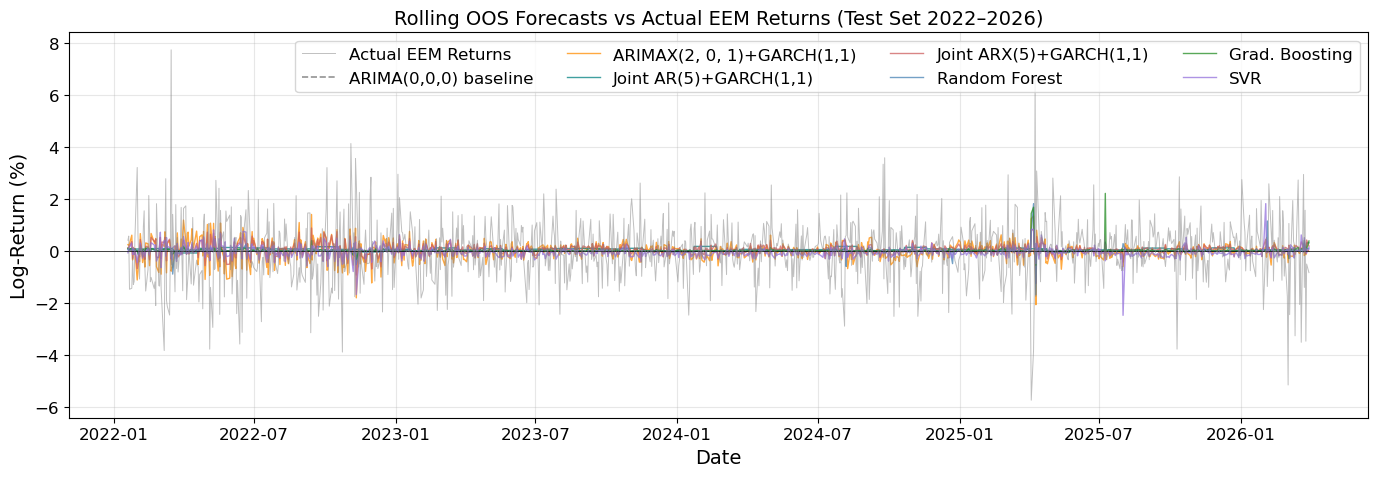

Fig 1 saved.


In [19]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(actual_s.index, actual_s.values * 100,
        color='gray', lw=0.7, alpha=0.5, label='Actual EEM Returns', zorder=5)
ax.plot(common_idx, bl_pred     * 100, color='gray',         lw=1.2,
        linestyle='--', alpha=0.85, label='ARIMA(0,0,0) baseline')
ax.plot(common_idx, arimax_pred * 100, color='darkorange',   lw=1.0,
        alpha=0.75, label=axg_label)
ax.plot(common_idx, jar_pred * 100, color='teal', lw=1.0,
        alpha=0.75, label=jar_label)
ax.plot(common_idx, jarx_pred * 100, color='indianred', lw=1.0,
        alpha=0.75, label=jarx_label)
ax.plot(common_idx, rf_pred     * 100, color='steelblue',    lw=1.0,
        alpha=0.75, label='Random Forest')
ax.plot(common_idx, gb_pred     * 100, color='forestgreen',  lw=1.0,
        alpha=0.75, label='Grad. Boosting')
ax.plot(common_idx, svr_pred    * 100, color='mediumpurple', lw=1.0,
        alpha=0.75, label='SVR')

ax.axhline(0, color='black', lw=0.5)
ax.set_title('Rolling OOS Forecasts vs Actual EEM Returns (Test Set 2022–2026)')
ax.set_xlabel('Date')
ax.set_ylabel('Log-Return (%)')
ax.legend(loc='upper right', ncol=4)
plt.tight_layout()
plt.savefig('../reports/figures/nb03_fig1_forecasts.pdf', bbox_inches='tight')
plt.show()
print("Fig 1 saved.")




### Figure 2 — Out-of-Sample RMSE Comparison

**What it shows:** Horizontal bar chart of OOS RMSE for all five models.
The dashed vertical line marks the ARIMA(0,0,0) random walk baseline.

**Thesis use:** Clean visual summary of the model comparison table.
If all bars are approximately equal — and none substantially shorter than
the baseline — this confirms the DM test result: no model adds economically
meaningful forecast improvement over the random walk.


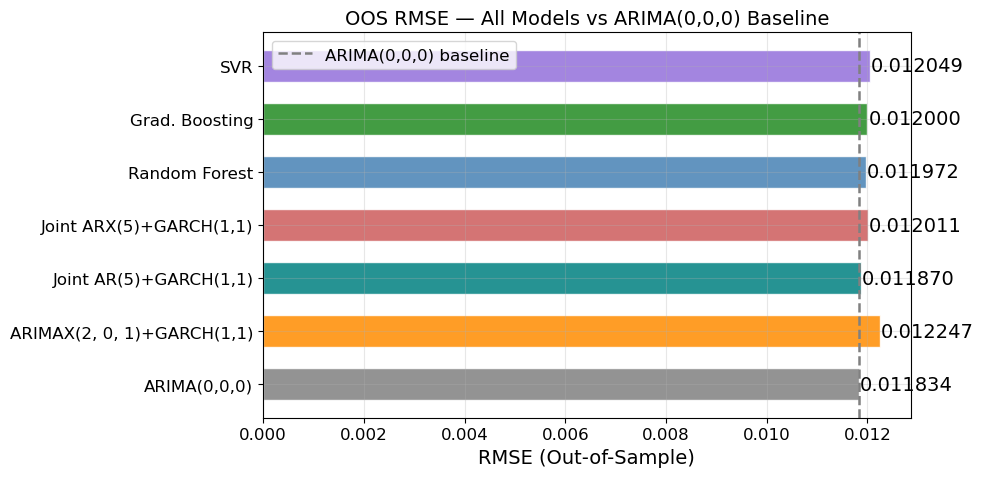

Fig 2 saved.


In [20]:
names_order = ['ARIMA(0,0,0)', axg_label, jar_label, jarx_label,
               'Random Forest', 'Grad. Boosting', 'SVR']
pred_arrays = [bl_pred, arimax_pred, jar_pred, jarx_pred, rf_pred, gb_pred, svr_pred]
rmse_vals   = [np.sqrt(np.mean((actual_s.values - p)**2)) for p in pred_arrays]
colors_bar  = [model_colors.get(n, 'steelblue') for n in names_order]
baseline_rmse = rmse_vals[0]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(range(len(names_order)), rmse_vals,
        color=colors_bar, alpha=0.85, edgecolor='white', height=0.6)
ax.set_yticks(range(len(names_order)))
ax.set_yticklabels(names_order)
ax.set_xlabel('RMSE (Out-of-Sample)')
ax.set_title('OOS RMSE — All Models vs ARIMA(0,0,0) Baseline')
ax.axvline(baseline_rmse, color='gray', linestyle='--', lw=1.8,
           label='ARIMA(0,0,0) baseline')
for i, v in enumerate(rmse_vals):
    ax.text(v + baseline_rmse * 0.002, i, f'{v:.6f}', va='center')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/nb03_fig2_rmse.pdf', bbox_inches='tight')
plt.show()
print("Fig 2 saved.")





### Figure 3 — Rolling 63-Day RMSE Over Time

**What it shows:** RMSE over a rolling 63-trading-day window (~3 months) for
each model on the test period.

**Thesis use:** Reveals whether any model outperforms in specific market regimes
(e.g. high-volatility crises). If ML models only "beat" the baseline during calm
low-volatility periods while underperforming during crises — this is informative
about model limitations and supports the EMH conclusion.


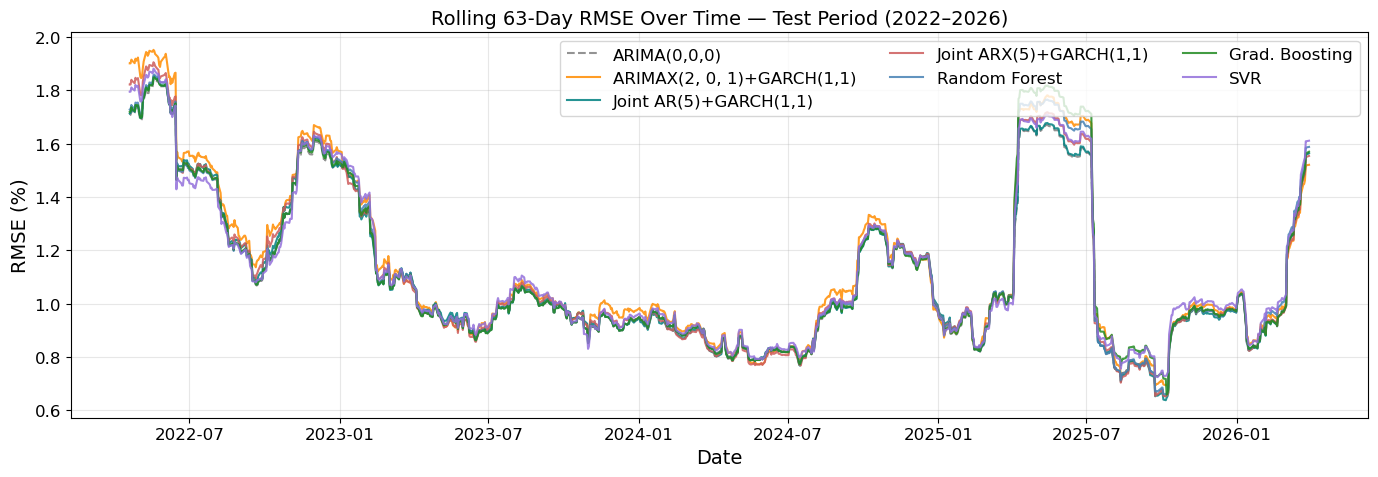

Fig 3 saved.


In [21]:
window = 63
fig, ax = plt.subplots(figsize=(14, 5))

for name, pred_arr, color, ls in [
    ('ARIMA(0,0,0)', bl_pred,     'gray',         '--'),
    (axg_label,      arimax_pred, 'darkorange',   '-'),
    (jar_label,      jar_pred,    'teal',         '-'),
    (jarx_label,     jarx_pred,   'indianred',    '-'),
    ('Random Forest',rf_pred,     'steelblue',    '-'),
    ('Grad. Boosting',gb_pred,    'forestgreen',  '-'),
    ('SVR',          svr_pred,    'mediumpurple', '-'),
]:
    sq_err    = (actual_s.values - pred_arr) ** 2
    roll_rmse = pd.Series(sq_err, index=actual_s.index).rolling(window).mean() ** 0.5
    ax.plot(roll_rmse.index, roll_rmse.values * 100,
            label=name, color=color, lw=1.5, linestyle=ls, alpha=0.85)

ax.set_title(f'Rolling {window}-Day RMSE Over Time — Test Period (2022–2026)')
ax.set_ylabel('RMSE (%)')
ax.set_xlabel('Date')
ax.legend( ncol=3)
plt.tight_layout()
plt.savefig('../reports/figures/nb03_fig3_rolling_rmse.pdf', bbox_inches='tight')
plt.show()
print("Fig 3 saved.")




### Figure 4 — Feature Importance: Random Forest vs Gradient Boosting

**What it shows:** Normalized feature importances from the last fitted Random Forest
and XGBoost models (trained on the full training set). Features sorted by RF importance.

**Thesis use:** Shows which cross-asset factors and EEM lags the ML models rely on
most. If EEM lags dominate over cross-asset features, the model is mainly exploiting
autocorrelation — consistent with the ARIMA structure. If cross-asset features
dominate, the model is using semi-strong EMH information. Either way, since the
DM test is not rejected, this information is not enough to beat the random walk OOS.


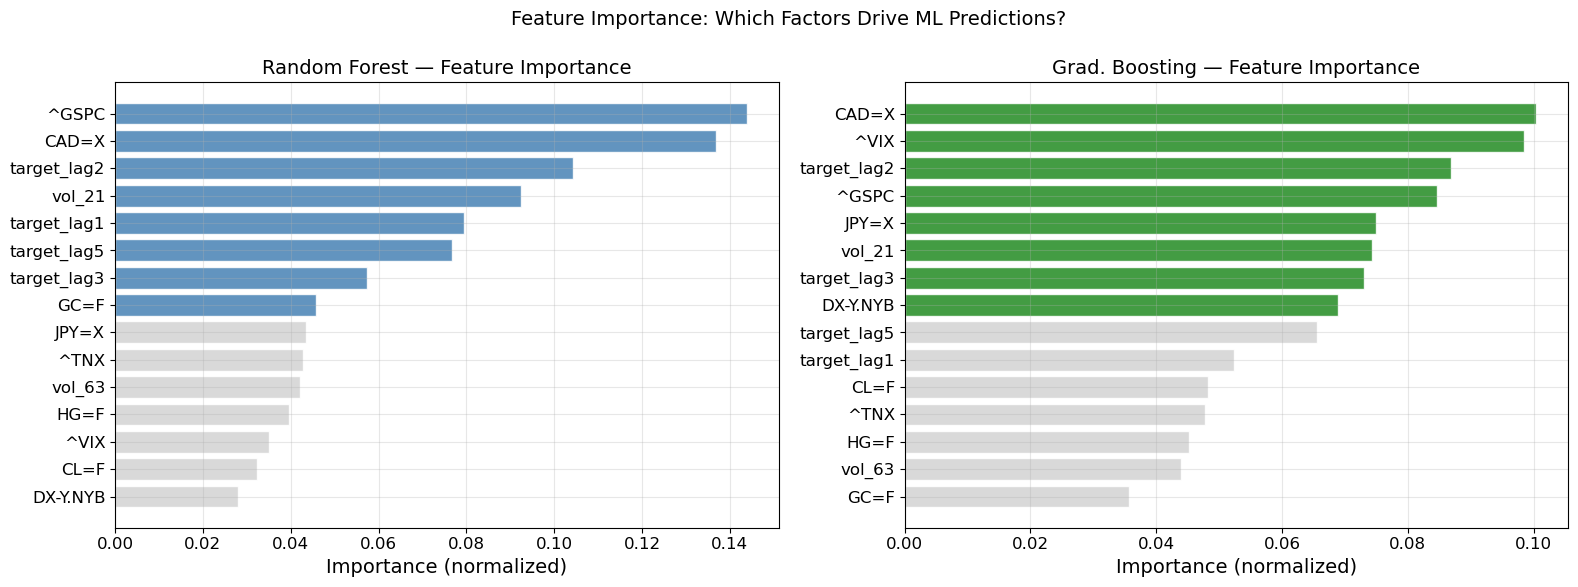

Fig 4 saved.


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, col, name, color in [
    (axes[0], 'RF importance', 'Random Forest',   'steelblue'),
    (axes[1], 'GB importance', 'Grad. Boosting',  'forestgreen'),
]:
    data = importances.set_index('feature')[col].sort_values(ascending=True)
    bar_colors = [color if v >= data.median() else 'lightgray' for v in data.values]
    ax.barh(data.index, data.values, color=bar_colors, alpha=0.85, edgecolor='white')
    ax.axvline(0, color='black', lw=0.6)
    ax.set_title(f'{name} — Feature Importance')
    ax.set_xlabel('Importance (normalized)')

plt.suptitle('Feature Importance: Which Factors Drive ML Predictions?')
plt.tight_layout()
plt.savefig('../reports/figures/nb03_fig4_importance.pdf', bbox_inches='tight')
plt.show()
print("Fig 4 saved.")




### Figure 5 — Block Permutation Test: RMSE Distribution

**What it shows:** For each ML model, a histogram of RMSE values obtained by
fitting on 200 block-permuted training sets vs the actual RMSE (red vertical line).

**Thesis use:** If the real RMSE is NOT in the left tail of the permutation
distribution (p-value > 0.05), the model learns noise rather than exploitable signal.
This is the most rigorous test of whether ML models find real structure —
it controls for spurious patterns without assuming any distribution.


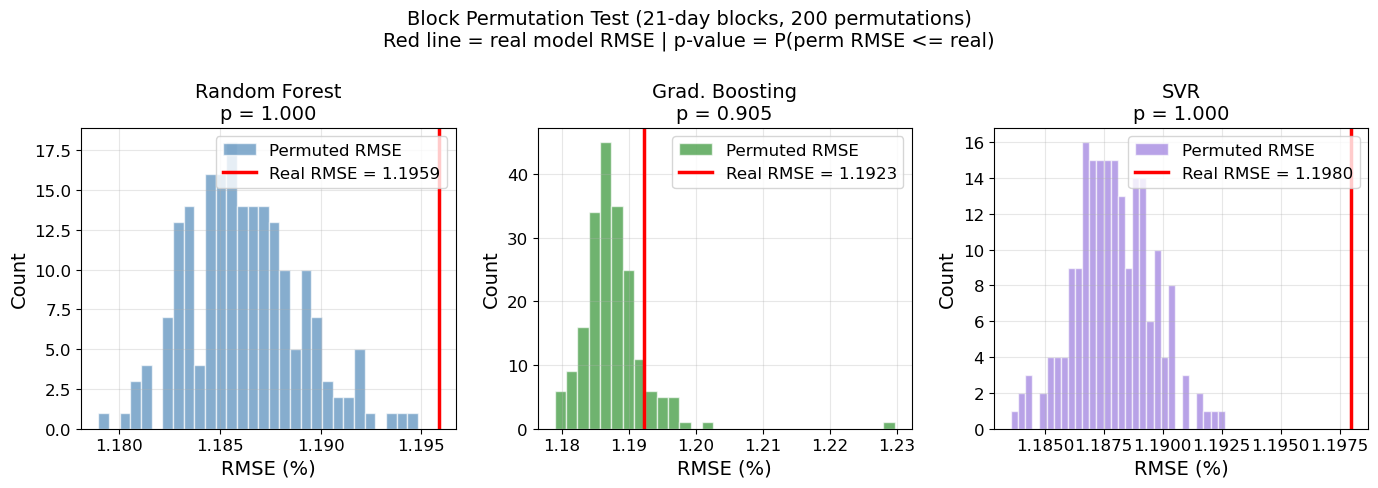

Fig 5 saved.

 All 5 figures saved to ../reports/figures/


In [23]:
model_names_perm = list(perm_rmses_dict.keys())
n_models = len(model_names_perm)
perm_colors = ['steelblue', 'forestgreen', 'mediumpurple']

fig, axes = plt.subplots(1, n_models, figsize=(14, 5))
if n_models == 1:
    axes = [axes]

for ax, (name, (real_rmse, perm_rmses)), color in zip(axes, perm_rmses_dict.items(), perm_colors):
    p_val = float(np.mean(np.array(perm_rmses) <= real_rmse))
    ax.hist(np.array(perm_rmses) * 100, bins=30, color=color, alpha=0.65,
            edgecolor='white', label='Permuted RMSE')
    ax.axvline(real_rmse * 100, color='red', lw=2.5, linestyle='-',
               label=f'Real RMSE = {real_rmse*100:.4f}')
    ax.set_title(f'{name}\np = {p_val:.3f}')
    ax.set_xlabel('RMSE (%)')
    ax.set_ylabel('Count')
    ax.legend()

plt.suptitle('Block Permutation Test (21-day blocks, 200 permutations)\n'
             'Red line = real model RMSE | p-value = P(perm RMSE <= real)')
plt.tight_layout()
plt.savefig('../reports/figures/nb03_fig5_permutation.pdf', bbox_inches='tight')
plt.show()
print("Fig 5 saved.")
print("\n All 5 figures saved to ../reports/figures/")



